In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
column_names = [
    "CrimeRate",  # The per capita crime rate by town. lower housing values
    "ResidentialLandZoned", # The proportion of residential land zoned for lots over 25,000 sq.ft.
    "IndustrialLandUse", # The proportion of non-retail business acres per town.
    "CharlesRiver", # Charles River dummy variable (1 if tract bounds river; 0 otherwise)
    "NitrixOxide", # Nitric oxides concentration (parts per 10 million)
    "AvgRoomPerDwelling", # The average number of rooms per dwelling
    "HousingAge", # The proportion of owner-occupied units built prior to 1940
    "DistanceToWork", # Weighted distances to five Boston employment centres
    "HighwayAccess", # Index of accessibility to radial highways
    "PropertyTaxRate", # Full-value property-tax rate per $10,000
    "Pupil-TeacherRatio", # The pupil-teacher ratio by town
    "B", # 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
    "LowSocioEcomic", # The percentage of lower status of the population
    "Value", # Median value of owner-occupied homes in $1000s
]
df = pd.read_csv("data/housing.csv", sep=r"\s+", header=None, names=column_names)

In [21]:
df.head(2)

,CrimeRate,ResidentialLandZoned,IndustrialLandUse,CharlesRiver,NitrixOxide,AvgRoomPerDwelling,HousingAge,DistanceToWork,HighwayAccess,PropertyTaxRate,Pupil-TeacherRatio,B,LowSocioEcomic,Value
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.9,9.14,21.6


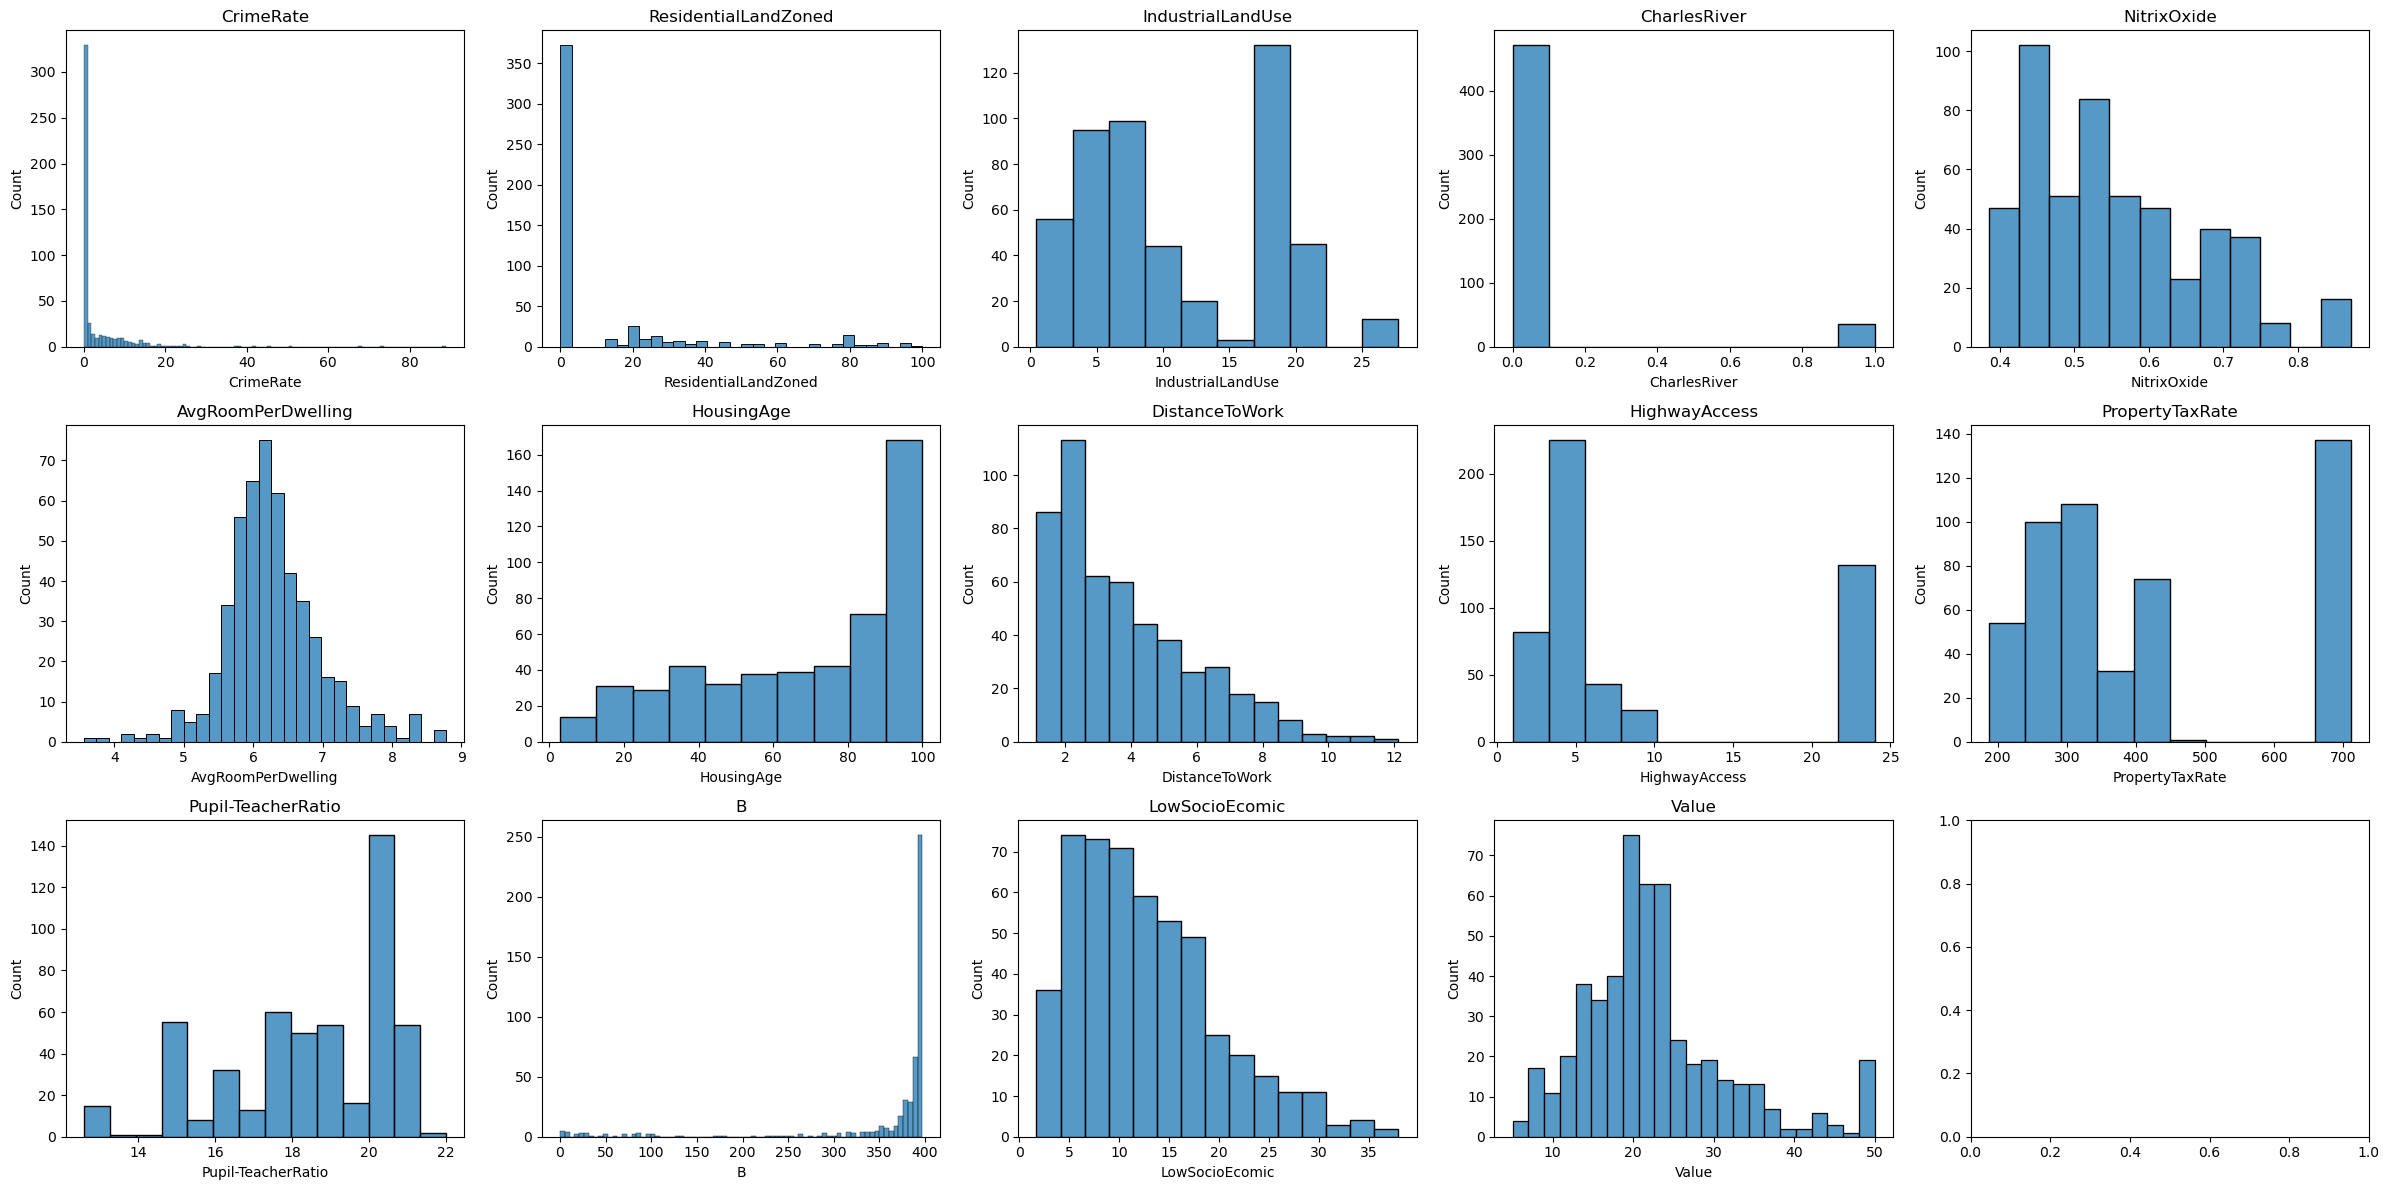

In [22]:
fig , axs = plt.subplots(3, 5, figsize=(24, 12))

for i, feature in enumerate(df.columns):
    row, col = divmod(i, 5)
    sns.histplot(df[feature], ax=axs[row][col])
    axs[row][col].set_title(feature)
plt.tight_layout()


In [3]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
feature_cols = ["CrimeRate", "ResidentialLandZoned", "IndustrialLandUse", "CharlesRiver", "NitrixOxide", "AvgRoomPerDwelling", "HousingAge", "DistanceToWork", "HighwayAccess", "PropertyTaxRate", "Pupil-TeacherRatio", "B", "LowSocioEcomic"]
X = df[feature_cols]
y = df['Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [4]:
preds = xgb_model.predict(X_test)


# Feature Importance

<Axes: >

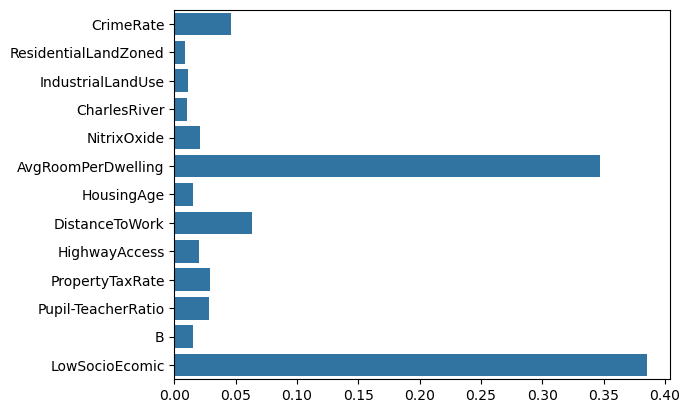

In [40]:
sns.barplot(x=xgb_model.feature_importances_, y=feature_cols)   

# **SHAP (SHapley Additive exPlanations)**
- assigns each feature an importance value for a particular prediction. 
- It is built on concepts from cooperative game theory, specifically Shapley values, which provide a way to fairly distribute the “payout” (in our case, the prediction) among the different “players” (how much each player contributes to the overall success of the game).
- Marginal Contribution of features
- Fair Distribution: Due to its axiomatic properties (efficiency, symmetry, dummy, and additivity), the Shapley value guarantees a fair and consistent distribution of the total prediction value among the features.


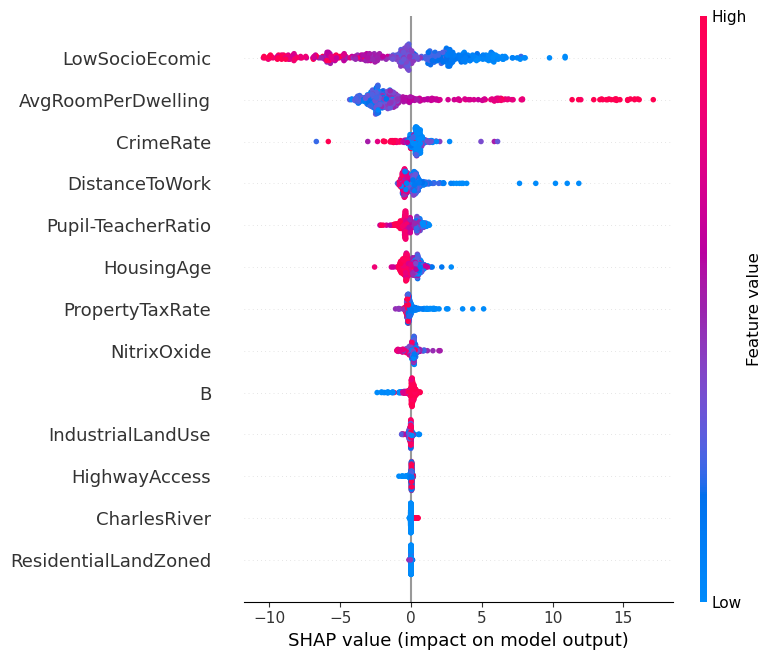

In [7]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, feature_names=feature_cols)


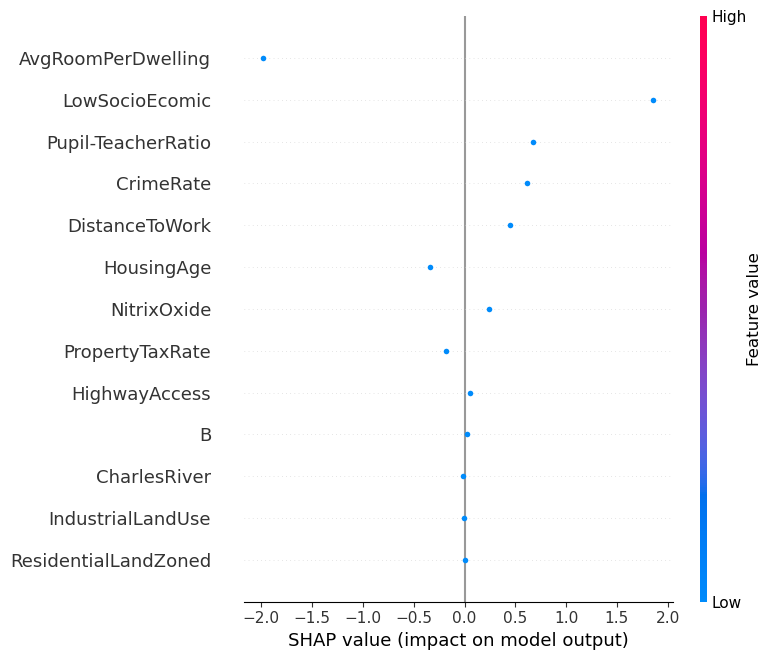

In [8]:
shap_values_test = explainer.shap_values(X_test.iloc[0:1])
shap.summary_plot(shap_values_test, X_test.iloc[0:1], feature_names=feature_cols)


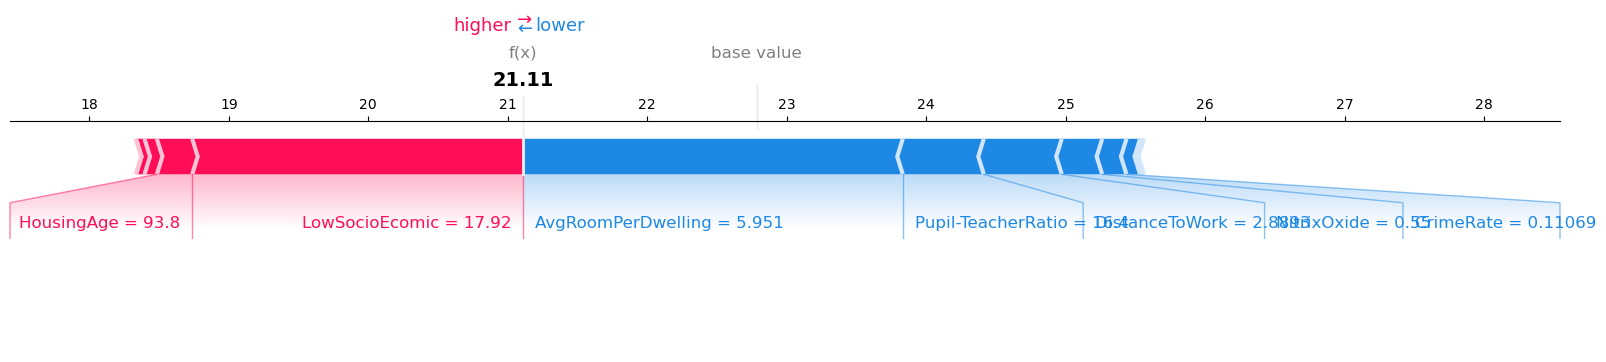

In [11]:
instance_index = 10
import matplotlib

shap.initjs()
# Generate and display the force plot (in a Jupyter Notebook, it will be interactive)
shap.force_plot(
    explainer.expected_value,
    shap_values[instance_index, :],
    X_test.iloc[instance_index, :],
    feature_names=feature_cols,
     matplotlib=True,
)
# f"{shap.getjs()}{force_plot.html()}"
# from IPython.display import display_html
# display_html(shap_html)

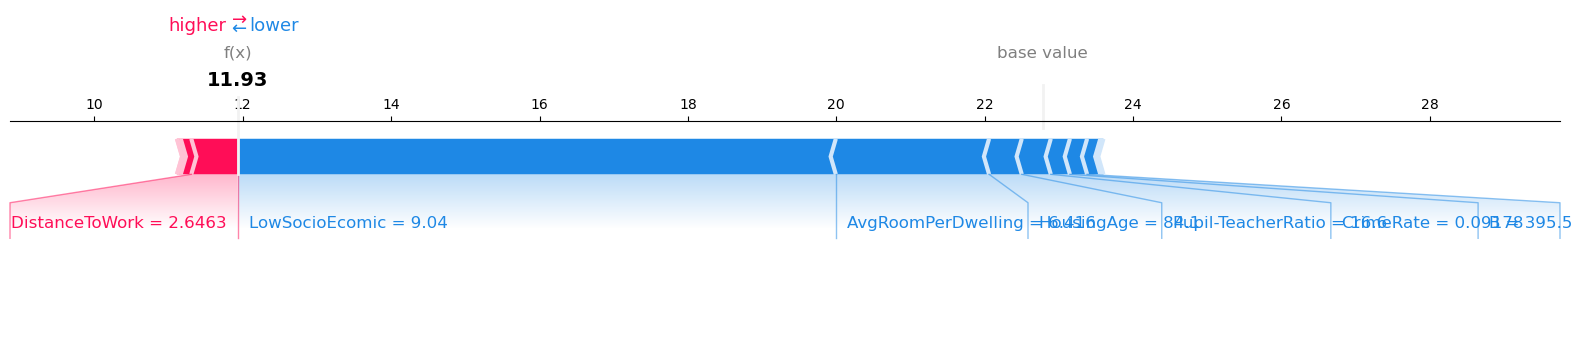

In [13]:
instance_index = 0
import matplotlib

shap.initjs()
# Generate and display the force plot (in a Jupyter Notebook, it will be interactive)
shap.force_plot(
    explainer.expected_value,
    shap_values[instance_index, :],
    X_test.iloc[instance_index, :],
    feature_names=feature_cols,
     matplotlib=True,
)

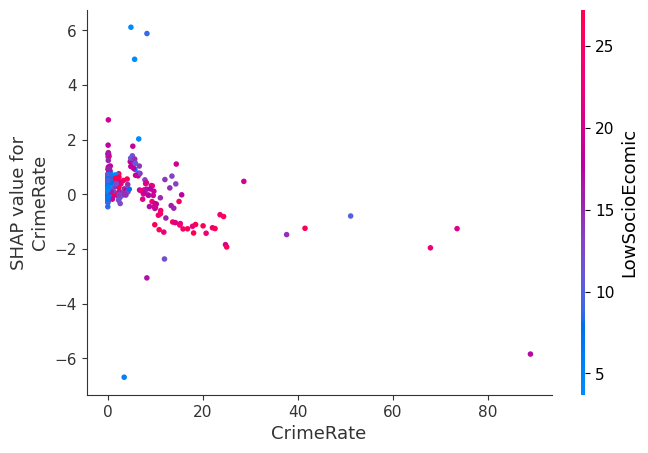

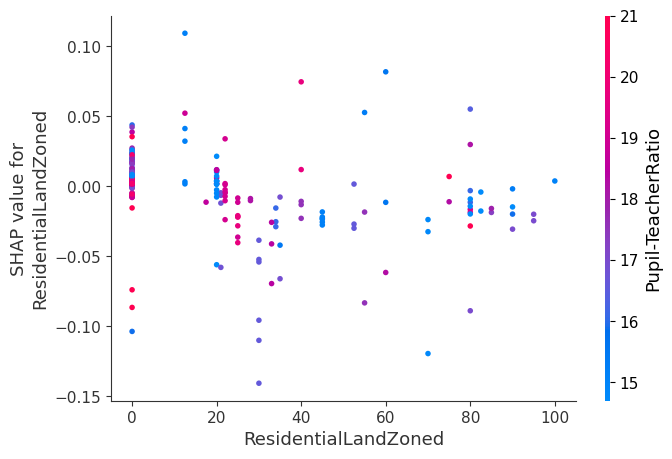

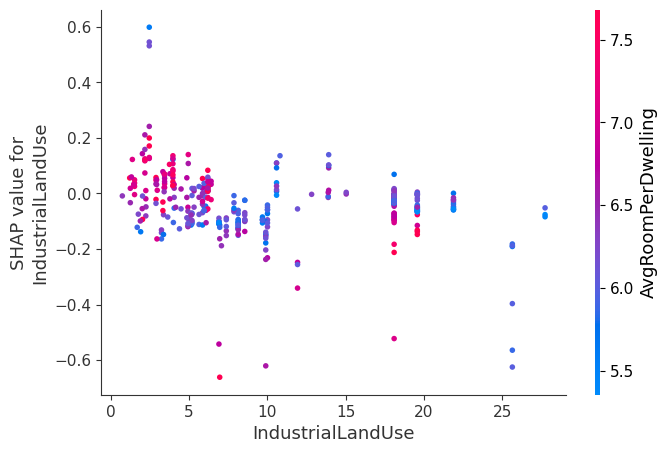

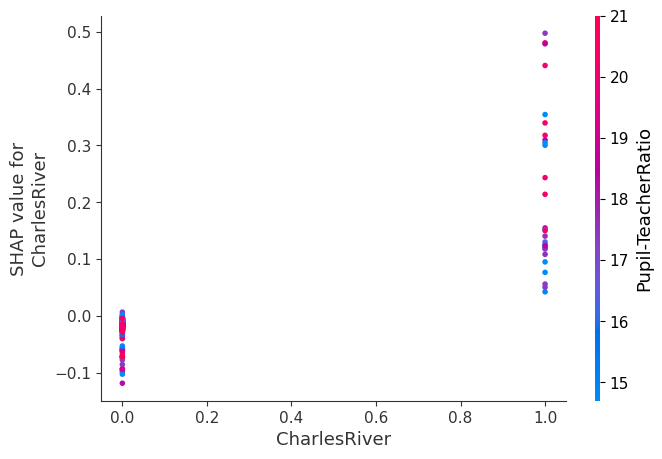

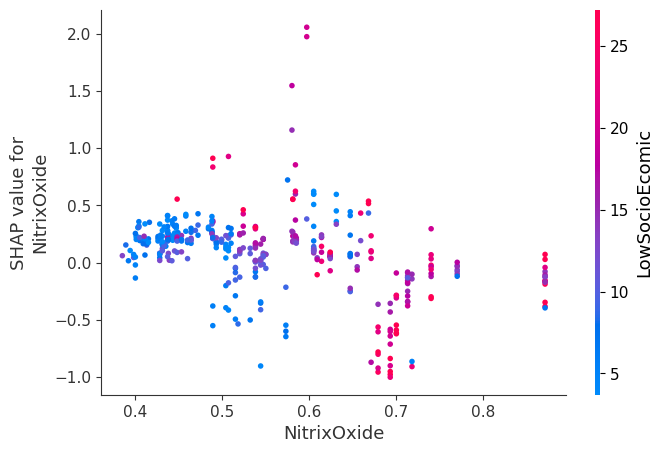

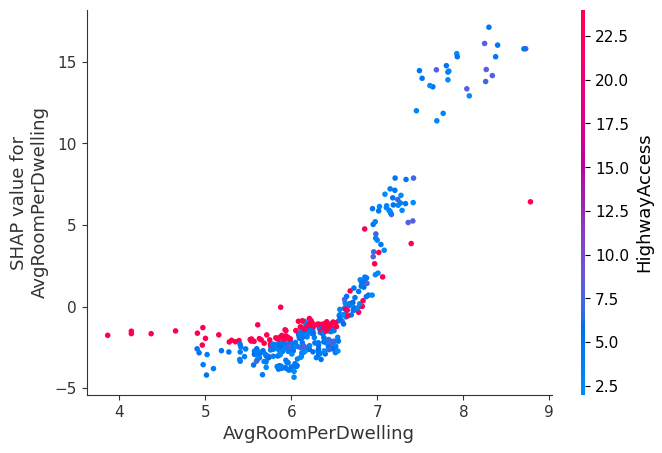

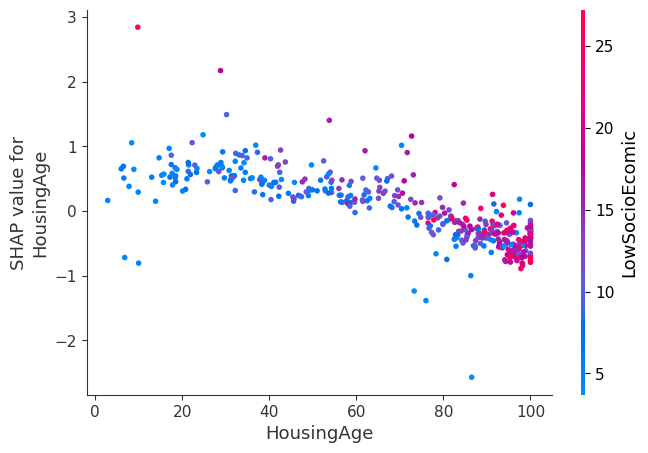

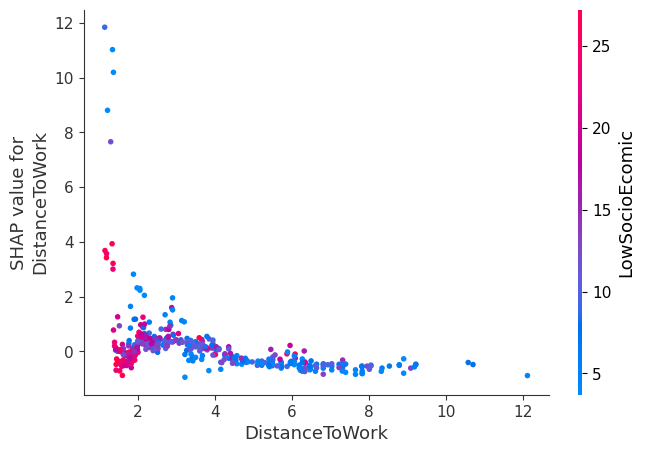

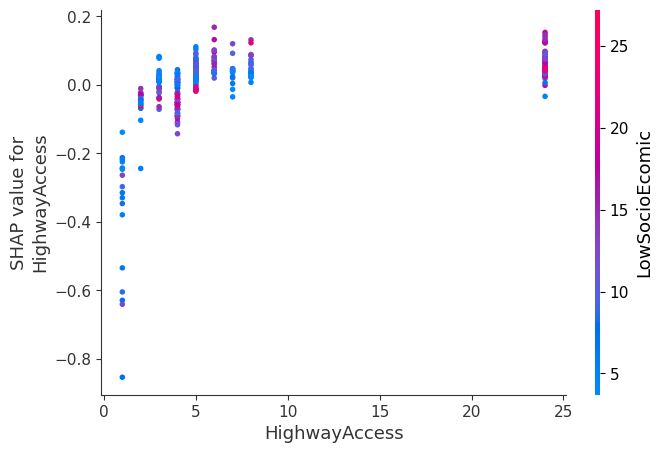

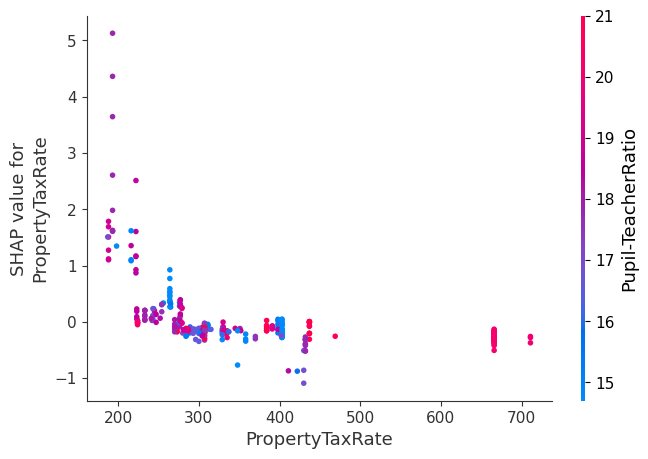

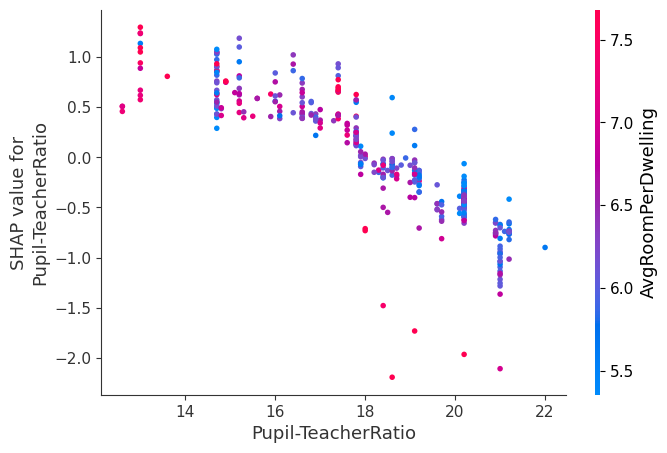

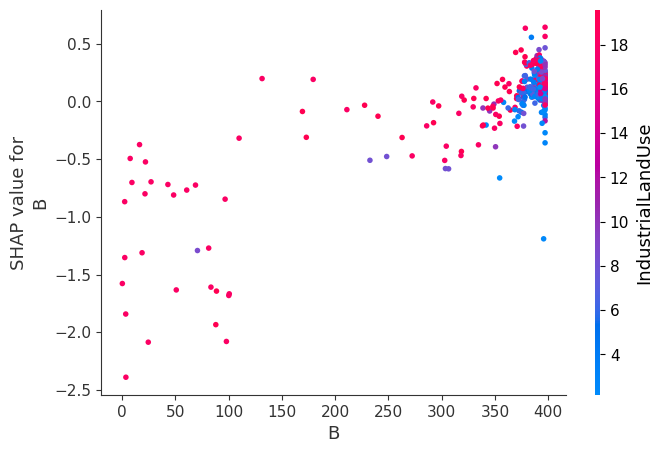

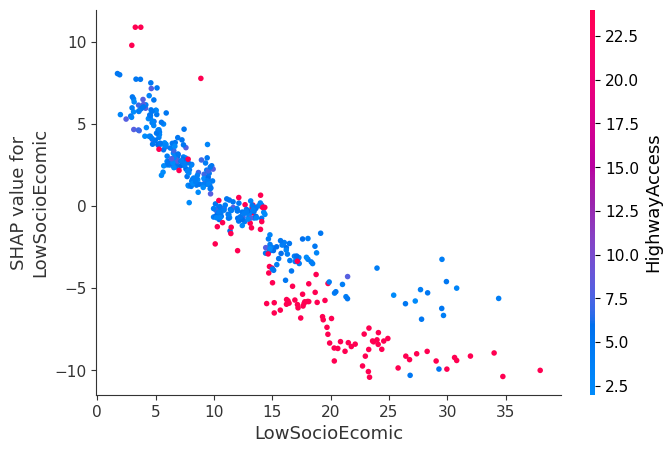

In [36]:
for feature in feature_cols:
    shap.dependence_plot(feature, shap_values, X_train, feature_names=feature_cols)


In [40]:
X_train.values[:5, :]

array([[1.50234e+01, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.14000e-01,
        5.30400e+00, 9.73000e+01, 2.10070e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 3.49480e+02, 2.49100e+01],
       [6.27390e-01, 0.00000e+00, 8.14000e+00, 0.00000e+00, 5.38000e-01,
        5.83400e+00, 5.65000e+01, 4.49860e+00, 4.00000e+00, 3.07000e+02,
        2.10000e+01, 3.95620e+02, 8.47000e+00],
       [3.46600e-02, 3.50000e+01, 6.06000e+00, 0.00000e+00, 4.37900e-01,
        6.03100e+00, 2.33000e+01, 6.64070e+00, 1.00000e+00, 3.04000e+02,
        1.69000e+01, 3.62250e+02, 7.83000e+00],
       [7.05042e+00, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.14000e-01,
        6.10300e+00, 8.51000e+01, 2.02180e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 2.52000e+00, 2.32900e+01],
       [7.25800e-01, 0.00000e+00, 8.14000e+00, 0.00000e+00, 5.38000e-01,
        5.72700e+00, 6.95000e+01, 3.79650e+00, 4.00000e+00, 3.07000e+02,
        2.10000e+01, 3.90950e+02, 1.12800e+01]])

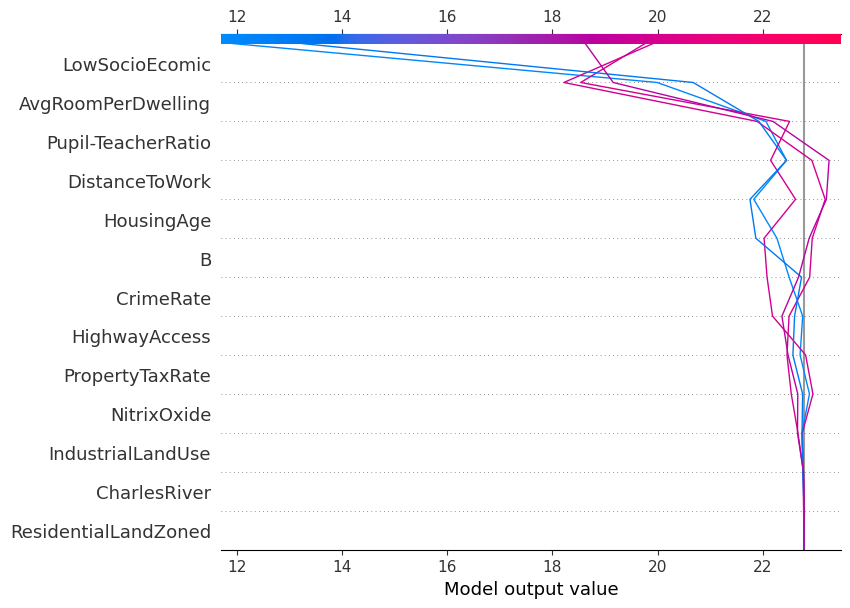

In [41]:
shap.decision_plot(explainer.expected_value, shap_values[:5, :], X_train.values[:5, :], feature_names=feature_cols)


# Lime

c:\ProgramData\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\ProgramData\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\ProgramData\anaconda3\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, 

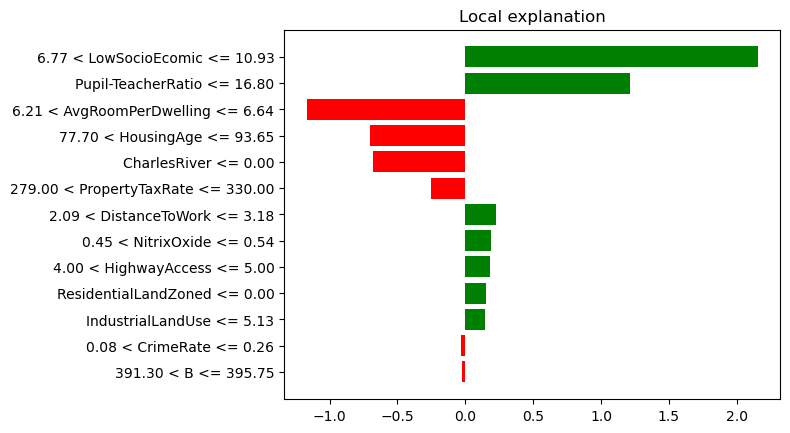

In [47]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(X_train.values, feature_names=feature_cols, class_names=['Value'], mode='regression')

exp = explainer.explain_instance(X_test.iloc[0], xgb_model.predict, num_features=len(feature_cols))

fig = exp.as_pyplot_figure()


# Explainability

| **Aspect**                | **LIME**                                                                                  | **SHAP**                                                                                                   | **Model-Based Feature Importance**                                   |
|---------------------------|-------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------|
| **Explanation Type**      | Local, instance-level                                                                     | Both local and global                                                                                      | Global                                                               |
| **Approach**              | Perturbation + local linear surrogate model                                               | Shapley values from cooperative game theory                                                                | Impurity reduction or permutation-based                              |
| **Interpretability**      | Simple local surrogate; intuitive for non-technical stakeholders                          | Theoretically sound additive contributions; rich visualizations available                                  | Straightforward ranking by average impact                            |
| **Computational Cost**    | Moderate per-instance; sampling can be slow for many instances                             | Can be computationally intensive (especially Kernel SHAP), but efficient with tree-based models (TreeExplainer) | Very efficient; computed during model training                       |
| **Global vs. Local Scope**| Provides only local explanations (one instance at a time)                                  | Offers both local explanations and aggregated global insights                                              | Only provides global importance; no individual prediction breakdown   |
| **Sensitivity & Stability**| Can be sensitive to sampling; results may vary with perturbations                            | Consistent and robust due to Shapley axioms                                                                  | May be biased (e.g., favoring features with more levels or categories) |

